In [7]:
## Model evaluation — test-set profit comparison

Load coordinated RL, myopic, and single-market rolling-intrinsic **daily** `profit.csv` files and merge on **delivery calendar day** (Europe/Berlin). The RL file defines which days are in scope.

**Choose the RL run** with `SELECTED_MODEL` (folder `output/coordinated_multi_market/logging/<id>/`). Training ranges for each id are in `evaluation/rl_model_registry.py`.

Run from the **repository root** or from `evaluation/` (paths adjusted in the next cell).

In [1]:
# --- only switch you need for coordinated RL outputs ---
SELECTED_MODEL = "1"  # "0" … "5"; see evaluation.rl_model_registry.RL_MODEL_REGISTRY

from pathlib import Path
import sys

import os
folder = "plots_rl_model_eval"
os.makedirs(folder, exist_ok=True)

_root = Path.cwd().resolve()
if _root.name == "evaluation":
    sys.path.insert(0, str(_root.parent))
else:
    sys.path.insert(0, str(_root))

import pandas as pd

from evaluation.merge_test_profits import build_test_comparison_df, default_paths_bs15
from evaluation.rl_model_registry import get_rl_model_spec, registry_as_dataframe

spec = get_rl_model_spec(SELECTED_MODEL)
print(spec.model_number, spec.describe_training())

paths = default_paths_bs15(SELECTED_MODEL)
from IPython.display import display

display(registry_as_dataframe())
paths

1 01.01.2019–31.03.2021 (Europe/Berlin)


,model_number,train_start,train_end_inclusive,train_end_exclusive,tensorboard_run_subdir
0,0,2019-01-01 00:00:00+01:00,2021-03-31 00:00:00+02:00,2021-04-01 00:00:00+02:00,PPO_0_1
1,1,2019-01-01 00:00:00+01:00,2021-03-31 00:00:00+02:00,2021-04-01 00:00:00+02:00,PPO_1_0
2,2,2023-01-01 00:00:00+01:00,2025-03-01 00:00:00+01:00,2025-03-02 00:00:00+01:00,PPO_2_1
3,3,2023-01-01 00:00:00+01:00,2025-03-01 00:00:00+01:00,2025-03-02 00:00:00+01:00,PPO_3_0
4,4,2019-01-01 00:00:00+01:00,2024-09-30 00:00:00+02:00,2024-10-01 00:00:00+02:00,PPO_4_1
5,5,2019-01-01 00:00:00+01:00,2024-09-30 00:00:00+02:00,2024-10-01 00:00:00+02:00,PPO_5_0


{'model_number': '1',
 'train_start': '2019-01-01T00:00:00+01:00',
 'train_end_inclusive': '2021-03-31T00:00:00+02:00',
 'rl': '/Users/timflaschel/Documents/GitHub/BessBidder1/output/coordinated_multi_market/logging/1/rolling_intrinsic_intelligently_stacked_on_day_ahead_qh/bs15cr1rto0.86mc365mt10/profit.csv',
 'myopic': '/Users/timflaschel/Documents/GitHub/BessBidder1/output/myopic_multi_market/rolling_intrinsic_stacked_on_day_ahead_qh/bs15cr1rto0.86mc365mt10/profit.csv',
 'single_glob': 'output/single_market/rolling_intrinsic/ri_basic/qh/*/bs15cr1rto0.86mc365mt10/profit.csv',
 'single_file': '/Users/timflaschel/Documents/GitHub/BessBidder1/output/single_market/profit.csv'}

In [2]:
from pathlib import Path

# Prefer consolidated output/single_market/profit.csv; fall back to per-year glob if missing.
_single_csv = Path(paths["single_file"])
if _single_csv.is_file():
    df_test = build_test_comparison_df(
        paths["rl"],
        paths["myopic"],
        single_market_profit_csv=paths["single_file"],
    )
else:
    try:
        df_test = build_test_comparison_df(
            paths["rl"],
            paths["myopic"],
            single_market_glob=paths["single_glob"],
        )
    except FileNotFoundError:
        df_test = build_test_comparison_df(
            paths["rl"],
            paths["myopic"],
            single_market_profit_csv=paths["single_file"],
        )

df_test.head(10)

,delivery_day,day_rl,profit_rl_coordinated,profit_myopic,profit_single_market_ri
0,2021-04-01 00:00:00+02:00,2021-04-01 00:00:00+02:00,77.717315,92.200414,106.400831
1,2021-04-02 00:00:00+02:00,2021-04-02 00:00:00+02:00,166.266625,171.773142,160.882299
2,2021-04-03 00:00:00+02:00,2021-04-03 00:00:00+02:00,109.548671,108.628091,92.382040
3,2021-04-04 00:00:00+02:00,2021-04-04 00:00:00+02:00,154.540957,135.974138,143.309281
4,2021-04-05 00:00:00+02:00,2021-04-05 00:00:00+02:00,232.071455,246.913258,283.404847
5,2021-04-06 00:00:00+02:00,2021-04-06 00:00:00+02:00,267.898332,277.790859,275.327106
6,2021-04-07 00:00:00+02:00,2021-04-07 00:00:00+02:00,136.549838,137.939105,133.295551
7,2021-04-08 00:00:00+02:00,2021-04-08 00:00:00+02:00,127.221737,122.879300,126.882185
8,2021-04-09 00:00:00+02:00,2021-04-09 00:00:00+02:00,100.768890,94.549413,90.287894
9,2021-04-10 00:00:00+02:00,2021-04-10 00:00:00+02:00,121.707625,128.785421,116.464835


In [3]:
# Coverage check: baselines should have rows for each RL test day
summary = pd.DataFrame(
    {
        "rows": [len(df_test)],
        "myopic_missing": [df_test["profit_myopic"].isna().sum()],
        "single_market_missing": [df_test["profit_single_market_ri"].isna().sum()],
    }
)
summary

,rows,myopic_missing,single_market_missing
0,183,0,0


### Brute-force upper bound (per-day `summary_*.csv`)

For each test `delivery_day`, load `coordinated_market_upper_bound_analysis/results_merged/summary_YYYY-MM-DD.csv` and add **max / median / q75 / q90** of the `profit` column across all scenarios in that file.

For many repeated analyses you can later run `build_brute_force_long_cache()` once (see `evaluation/brute_force_summary_stats.py`).

In [4]:
from evaluation.brute_force_summary_stats import attach_brute_force_stats, default_results_merged_dir

df_test_bf = attach_brute_force_stats(df_test, on_missing="warn")
df_test_bf.head()

,delivery_day,day_rl,profit_rl_coordinated,profit_myopic,profit_single_market_ri,theoretical_max_profit,brute_median_profit,brute_q075_profit,brute_q090_profit,theoretical_max_da_profit,brute_median_da_profit,brute_q075_da_profit,brute_q090_da_profit,theoretical_max_idc_profit,brute_median_idc_profit,brute_q075_idc_profit,brute_q090_idc_profit
0,2021-04-01 00:00:00+02:00,2021-04-01 00:00:00+02:00,77.717315,92.200414,106.400831,117.956864,99.411648,107.720561,111.324238,20.8526,-7.1519,4.70305,11.14568,176.502029,108.175724,121.436054,137.678179
1,2021-04-02 00:00:00+02:00,2021-04-02 00:00:00+02:00,166.266625,171.773142,160.882299,192.907218,163.094569,174.238685,179.897878,64.5864,-11.9147,-1.62375,22.48000,256.173016,177.400645,194.823520,223.608744
2,2021-04-03 00:00:00+02:00,2021-04-03 00:00:00+02:00,109.548671,108.628091,92.382040,115.858681,102.531147,106.572748,110.101994,41.1878,-3.6701,5.27650,13.71580,164.614198,105.226087,116.218846,134.155512
3,2021-04-04 00:00:00+02:00,2021-04-04 00:00:00+02:00,154.540957,135.974138,143.309281,176.436141,143.379189,151.560586,160.445248,40.7070,-11.8442,-3.50590,16.88782,215.097541,154.794710,173.412296,187.349059
4,2021-04-05 00:00:00+02:00,2021-04-05 00:00:00+02:00,232.071455,246.913258,283.404847,339.618408,278.331090,293.804740,311.066889,76.6982,14.7660,36.71210,52.83482,334.770612,262.710845,290.555436,306.492083


### Day-ahead vs intraday split (from trades)

Rolling-intrinsic **total** daily € in `profit_*` columns come from `profit.csv`. **DA** vs **IDC** sums use the same rule as elsewhere: trades with **execution** at **13:00** (Europe/Berlin) count as day-ahead; all other rows as intraday (not the full 13:xx hour, so e.g. 13:45 intraday is IDC) (`evaluation.da_idc_profit_enrichment`, same logic as `daily_da_idc_profit_from_trades_file`).

- **`df_test_bf_da_idc`**: `df_test_bf` plus `profit_*_da`, `profit_*_idc`, `profit_*_da_share`, `profit_*_idc_share` for RL, myopic, and single-market columns (when trades exist).
- **`df_test_bf_day_ahead`** / **`df_test_bf_intraday`**: copies with the **same columns as `df_test_bf`**, but the three daily profit columns are replaced by the DA-only or IDC-only amounts; brute-force columns are unchanged.

To enrich a standalone `profit.csv` once on disk, use `enrich_rolling_intrinsic_profit_csv(profit_csv, trades_dir, output_path=...)`.


In [5]:
from pathlib import Path

from evaluation.da_idc_profit_enrichment import (
    attach_da_idc_to_comparison_df,
    day_ahead_profit_view,
    intraday_profit_view,
)
from evaluation.rl_model_registry import paths_for_coordinated_model

_repo = Path.cwd().resolve()
if _repo.name == "evaluation":
    _repo = _repo.parent

_paths_da = paths_for_coordinated_model(SELECTED_MODEL, repo_root=_repo)
_single_trades = _repo / "output" / "single_market" / "trades"

df_test_bf_da_idc = attach_da_idc_to_comparison_df(
    df_test_bf,
    rl_trades_dir=_paths_da["trades_dir"],
    myopic_trades_dir=_paths_da["myopic_trades_dir"],
    single_market_trades_dir=_single_trades,
    on_missing="warn",
)

df_test_bf_day_ahead = day_ahead_profit_view(df_test_bf_da_idc)
df_test_bf_intraday = intraday_profit_view(df_test_bf_da_idc)

df_test_bf_da_idc.head()


,delivery_day,day_rl,profit_rl_coordinated,profit_myopic,profit_single_market_ri,theoretical_max_profit,brute_median_profit,brute_q075_profit,brute_q090_profit,theoretical_max_da_profit,...,profit_rl_coordinated_da_share,profit_rl_coordinated_idc_share,profit_myopic_da,profit_myopic_idc,profit_myopic_da_share,profit_myopic_idc_share,profit_single_market_ri_da,profit_single_market_ri_idc,profit_single_market_ri_da_share,profit_single_market_ri_idc_share
0,2021-04-01 00:00:00+02:00,2021-04-01 00:00:00+02:00,77.717315,92.200414,106.400831,117.956864,99.411648,107.720561,111.324238,20.8526,...,0.21,0.79,30.854038,61.346376,0.33,0.67,2.823809,103.577023,0.03,0.97
1,2021-04-02 00:00:00+02:00,2021-04-02 00:00:00+02:00,166.266625,171.773142,160.882299,192.907218,163.094569,174.238685,179.897878,64.5864,...,0.07,0.93,68.131988,103.641154,0.40,0.60,4.455207,156.427092,0.03,0.97
2,2021-04-03 00:00:00+02:00,2021-04-03 00:00:00+02:00,109.548671,108.628091,92.382040,115.858681,102.531147,106.572748,110.101994,41.1878,...,0.16,0.84,49.746997,58.881093,0.46,0.54,0.266997,92.115043,0.00,1.00
3,2021-04-04 00:00:00+02:00,2021-04-04 00:00:00+02:00,154.540957,135.974138,143.309281,176.436141,143.379189,151.560586,160.445248,40.7070,...,0.01,0.99,52.120221,83.853917,0.38,0.62,3.721854,139.587426,0.03,0.97
4,2021-04-05 00:00:00+02:00,2021-04-05 00:00:00+02:00,232.071455,246.913258,283.404847,339.618408,278.331090,293.804740,311.066889,76.6982,...,-0.01,1.01,80.340389,166.572869,0.33,0.67,11.033370,272.371477,0.04,0.96


In [6]:
from evaluation.da_idc_profit_enrichment import profit_comparison_summary

df_profit_summary = profit_comparison_summary(df_test_bf_da_idc)
df_profit_summary


,Coordinated multi-market,Myopic multi-market,Single market (rolling intrinsic),Daily max (brute),Daily median (brute),Daily q75 (brute),Daily q90 (brute),Daily max DA (brute),Daily median DA (brute),Daily q75 DA (brute),Daily q90 DA (brute),Daily max IDC (brute),Daily median IDC (brute),Daily q75 IDC (brute),Daily q90 IDC (brute)
mean_total_profit,144.810344,140.191729,142.085553,168.186423,141.515475,148.713345,154.679117,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean_da_profit,13.376443,56.817429,3.318095,NaN,NaN,NaN,NaN,40.642954,-7.444321,10.113570,22.876780,NaN,NaN,NaN,NaN
mean_idc_profit,131.433901,83.374300,138.767458,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,260.065269,148.065989,166.149107,186.300805
total_profit_std,67.277265,65.891204,64.468455,76.396617,63.911426,66.884404,69.852316,25.155489,5.360926,11.270344,16.351065,87.366744,62.381716,69.281086,74.634349


In [15]:
df_profit_summary.columns

Index(['Coordinated multi-market', 'Myopic multi-market',
       'Single market (rolling intrinsic)', 'Daily max (brute)',
       'Daily median (brute)', 'Daily q75 (brute)', 'Daily q90 (brute)',
       'Daily max DA (brute)', 'Daily median DA (brute)',
       'Daily q75 DA (brute)', 'Daily q90 DA (brute)', 'Daily max IDC (brute)',
       'Daily median IDC (brute)', 'Daily q75 IDC (brute)',
       'Daily q90 IDC (brute)'],
      dtype='object')

In [7]:
df_test_bf.describe()

,profit_rl_coordinated,profit_myopic,profit_single_market_ri,theoretical_max_profit,brute_median_profit,brute_q075_profit,brute_q090_profit,theoretical_max_da_profit,brute_median_da_profit,brute_q075_da_profit,brute_q090_da_profit,theoretical_max_idc_profit,brute_median_idc_profit,brute_q075_idc_profit,brute_q090_idc_profit
count,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000,183.000000
mean,144.810344,140.191729,142.085553,168.186423,141.515475,148.713345,154.679117,40.642954,-7.444321,10.113570,22.876780,260.065269,148.065989,166.149107,186.300805
std,67.277265,65.891204,64.468455,76.396617,63.911426,66.884404,69.852316,25.155489,5.360926,11.270344,16.351065,87.366744,62.381716,69.281086,74.634349
min,53.778721,54.627816,55.617982,75.914817,60.943544,64.888876,69.524714,9.536400,-25.337200,-5.110900,1.435320,146.049990,65.889918,75.634455,86.031541
25%,98.681207,92.254630,96.328620,113.538239,95.743135,100.559585,104.005156,20.990700,-10.570450,3.220300,11.875690,199.300096,103.757141,116.194756,130.424330
50%,124.866627,120.253871,122.638870,146.193759,121.787708,127.696889,133.603410,32.259600,-7.689700,6.636600,17.131200,236.921570,126.922452,142.941945,165.345222
75%,173.092696,165.646434,173.645900,199.565942,172.440428,179.041725,187.921838,51.805100,-5.037700,14.265325,28.845000,297.917403,177.300370,195.816771,221.553737
max,387.423524,370.463733,349.342339,430.603454,351.017358,361.741945,397.878550,130.049800,14.766000,61.536550,88.913800,579.793140,363.509291,412.450973,452.493950


### Cumulative profit + SoC (coordinated RL, test days)

**Left:** stacked **cumulative** profit (€): day-ahead trades (`execution_time` hour == 13 Berlin) vs intraday, summed from each row’s `profit` in `trades/trades_YYYY-MM-DD.csv` (same colour/hatch idea as your thesis reference: teal DA, pink IDC).

**Right:** mean **DA** vs **actual** SoC bands (96×15 min delivery time), as before.

Set **`SOC_Q_LOW`** / **`SOC_Q_HIGH`** in the code cell; implementation: `evaluation.coordinated_rl_test_plots`.


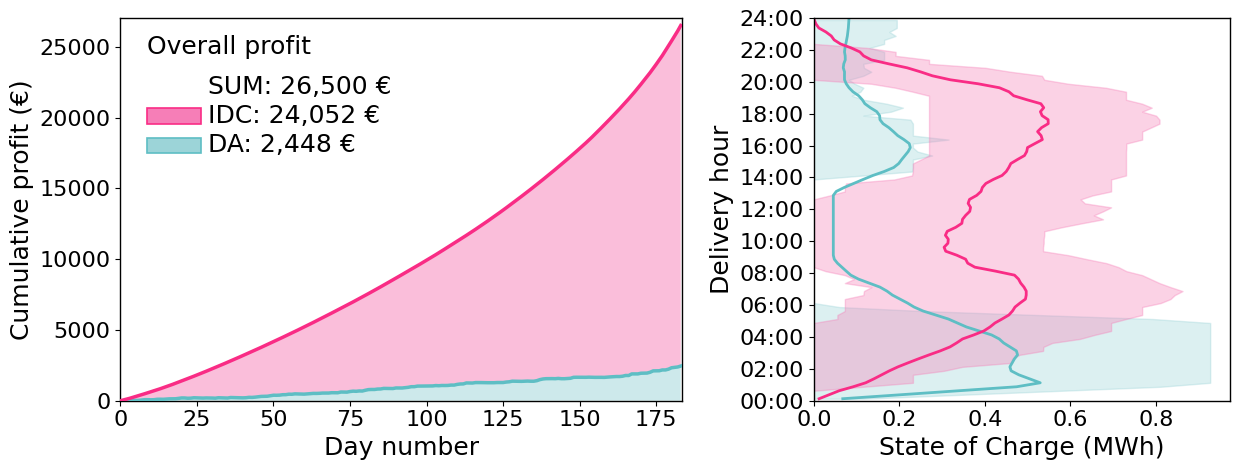

In [8]:
import matplotlib.pyplot as plt
from evaluation.coordinated_rl_test_plots import coordinated_rl_cumulative_profit_and_soc_figure

plot_name = "coordinated_rl_cumulative_profit_and_soc_figure"

# --- SoC band quantiles (change here; legend text updates automatically) ---
SOC_Q_LOW = 0.25
SOC_Q_HIGH = 0.75
assert 0.0 <= SOC_Q_LOW < SOC_Q_HIGH <= 1.0

fig, ax_cum, ax_soc, profit_tbl, mat_da, mat_all, s_da, s_all = (
    coordinated_rl_cumulative_profit_and_soc_figure(
        SELECTED_MODEL,
        df_test["delivery_day"],
        e_max_mwh=1.0,
        soc0_mwh=0.0,
        q_low=SOC_Q_LOW,
        q_high=SOC_Q_HIGH,
    )
)

filepath = os.path.join(folder, f"{plot_name}_model_{SELECTED_MODEL}.png")
plt.savefig(filepath, dpi=300, bbox_inches='tight')

plt.show()

### Cumulative profit + SoC (myopic multi-market, test days)

Same layout as coordinated RL: **left** = stacked cumulative DA vs intraday € from `output/myopic_multi_market/rolling_intrinsic_stacked_on_day_ahead_qh/<bs>/trades/`; **right** = mean DA vs actual SoC (swapped axes, no legend). Reuses **`SOC_Q_LOW`** / **`SOC_Q_HIGH`** from the cell above. Implementation: `evaluation.coordinated_rl_test_plots.myopic_cumulative_profit_and_soc_figure`.

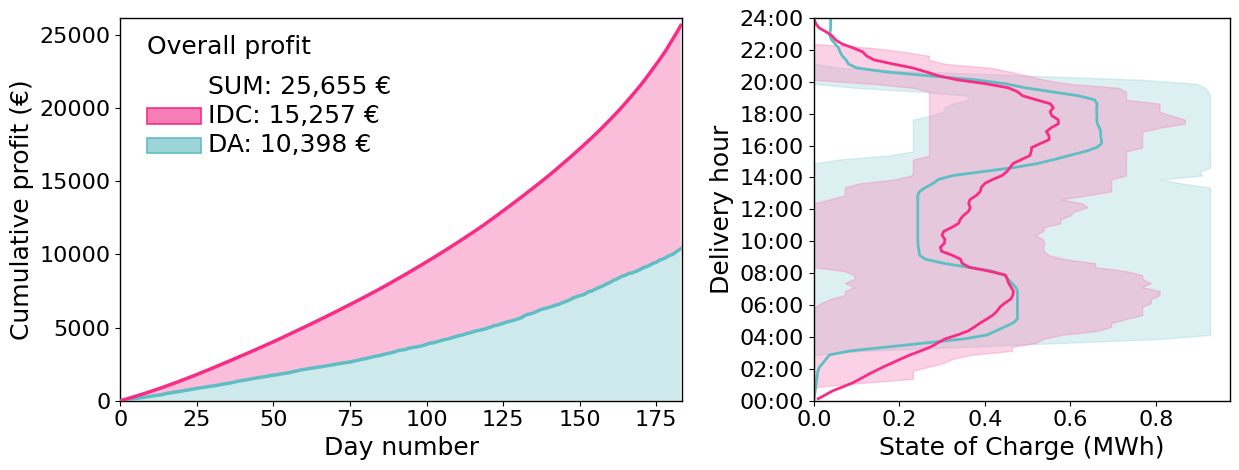

In [9]:
import matplotlib.pyplot as plt
from evaluation.coordinated_rl_test_plots import myopic_cumulative_profit_and_soc_figure

plot_name = "myopic_cumulative_profit_and_soc_figure"

fig_m, ax_cum_m, ax_soc_m, profit_tbl_m, mat_da_m, mat_all_m, s_da_m, s_all_m = (
    myopic_cumulative_profit_and_soc_figure(
        df_test["delivery_day"],
        e_max_mwh=1.0,
        soc0_mwh=0.0,
        q_low=SOC_Q_LOW,
        q_high=SOC_Q_HIGH,
    )
)
filepath = os.path.join(folder, f"{plot_name}_model_{SELECTED_MODEL}.png")
plt.savefig(filepath, dpi=300, bbox_inches='tight')
plt.show()

### SoC — myopic multi-market

Same as coordinated RL: **DA** (execution hour 13 Berlin) vs **actual** (all trades). Trades folder: `output/myopic_multi_market/.../trades/`.

Uses **`SOC_Q_LOW` / `SOC_Q_HIGH`** from the coordinated RL cell above (re-run that cell first if you change them).

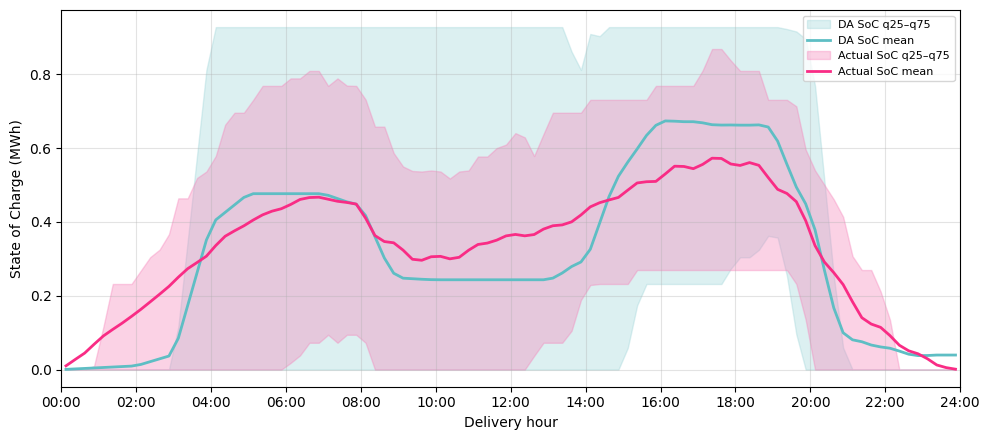

In [10]:
import matplotlib.pyplot as plt
from evaluation.soc_profiles import myopic_soc_plot_from_test_days

fig_m, ax_m, mat_da_m, mat_all_m, s_da_m, s_all_m = myopic_soc_plot_from_test_days(
    df_test["delivery_day"],
    e_max_mwh=1.0,
    soc0_mwh=0.0,
    q_low=SOC_Q_LOW,
    q_high=SOC_Q_HIGH,
)
fig_m.tight_layout()
plt.show()

### SoC — single-market rolling intrinsic

**No day-ahead trades** in this pipeline: only one band + mean (**all trades** / intraday). Trade files live under `output/single_market/.../qh/<year>/.../trades/`; the resolver picks the year folder that contains `trades_YYYY-MM-DD.csv`.

Uses **`SOC_Q_LOW` / `SOC_Q_HIGH`** from the coordinated RL cell.

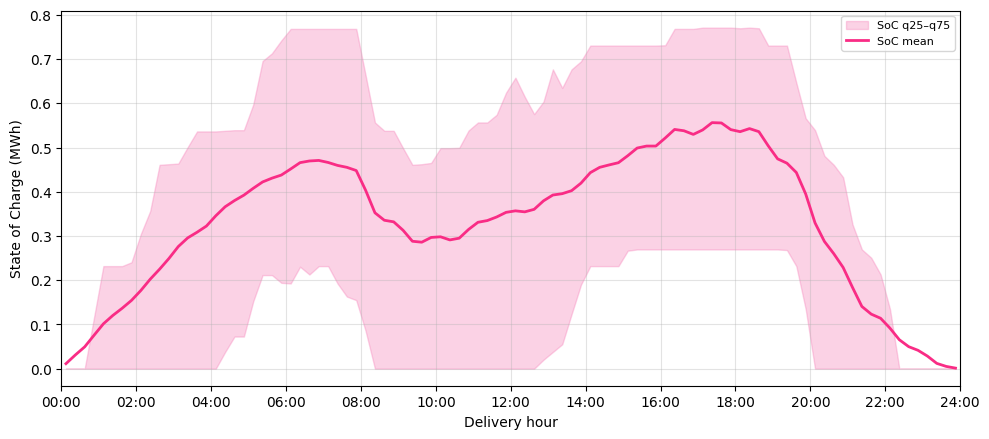

In [11]:
import matplotlib.pyplot as plt
from evaluation.soc_profiles import single_market_soc_plot_from_test_days

fig_s, ax_s, mat_all_s, s_all_s = single_market_soc_plot_from_test_days(
    df_test["delivery_day"],
    e_max_mwh=1.0,
    soc0_mwh=0.0,
    q_low=SOC_Q_LOW,
    q_high=SOC_Q_HIGH,
)
fig_s.tight_layout()
plt.show()

### Training vs validation profit (side by side)

**Left — TensorBoard (training):** mean **combined € profit** from `episode_profit/combined_eur` vs **environment timestep** (`output/coordinated_multi_market/tensorboard/<name>/`, see `evaluation.rl_model_registry`). **Raw** curve (faint) plus a **moving average** over the last `RL_TB_MOVING_AVG_WINDOW` samples (training only).

**Right — checkpoint sweep (validation):** `validation_precomputed/validation_summary.csv`: **x** = training **steps**, **y** = **`mean_profit`** (or **`profit`**) on the **validation holdout**. Checkpoints are shown as markers with a faint connecting line (**no** moving average on this panel).


**Horizontal guides (left):** **train-fit** days — **solid** lines: **Myopic multi-market**, **Single market (rolling intrinsic)**; **same dashed style**, **different colours**: **Daily max**, **Daily q90**, and **Best avg DA pattern** (`no_da` / `combo_id == 0` excluded; `evaluation.brute_force_summary_stats.best_mean_profit_da_pattern_over_days`).

**Horizontal guides (right):** **validation holdout** means; same line/colour rules. **Best pattern** line is the **same** train-winning pattern evaluated on validation days (`mean_profit_for_pattern_over_days`).

**Colours:** Seaborn **colorblind** hex values in the code cell; coordinated RL curves use the first swatch.

**Typography:** **x**/**y** axis **titles** and legend at 18 pt; **y** tick labels at 16 pt; **x** tick labels only at 12 pt.

**Legend:** one shared entry list under both panels (taken from the training axis); the validation **checkpoint** curve is not listed separately because it has no counterpart on the left.


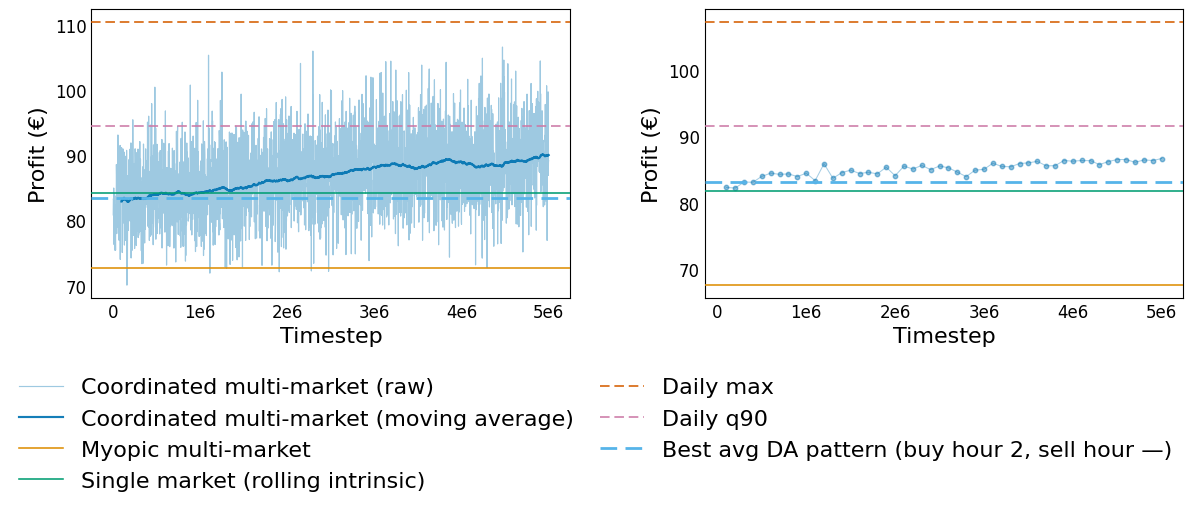

In [12]:
import matplotlib.pyplot as plt
import pandas as pd
from matplotlib.ticker import FuncFormatter, MultipleLocator

from evaluation.brute_force_summary_stats import (
    best_mean_profit_da_pattern_over_days,
    mean_profit_for_pattern_over_days,
)
from evaluation.rl_model_registry import rl_tensorboard_run_dir, rl_validation_summary_csv_path
from evaluation.tensorboard_rl_curves import EPISODE_PROFIT_COMBINED_TAG, load_tensorboard_scalar
from evaluation.training_period_baselines import (
    build_training_period_baselines_df,
    mean_reference_values_train_fit,
    mean_reference_values_validation_holdout,
)

plot_name = "training_vs_validation_profit_figure"

# y-axis label, legend, and x-axis *title*; y tick labels
LABEL_FONTSIZE = 16
TICK_FONTSIZE_Y = 12
# x-axis *tick* labels only (x-axis title stays LABEL_FONTSIZE)
X_TICK_FONTSIZE = 12

# Seaborn default "colorblind" palette (Wong-style) — same hex as seaborn.color_palette("colorblind")
_SEABORN_COLORBLIND = (
    "#0173B2",
    "#DE8F05",
    "#029E73",
    "#D55E00",
    "#CC79A7",
    "#F0E442",
    "#56B4E9",
    "#009E73",
)
_RL_BLUE = _SEABORN_COLORBLIND[0]

# Rolling mean over this many TensorBoard samples (training panel only)
RL_TB_MOVING_AVG_WINDOW = 200

# Still returned by baselines helpers; omit from the figure (legend + lines)
SKIP_REF_KEYS = frozenset({"mean_brute_q075_eur"})

# Solid: myopic, single-market RI. Shared non-solid style: daily max, daily q90, best DA pattern
_SOLID_REF_KEYS = frozenset({"mean_myopic_eur", "mean_single_market_ri_eur"})
_LS_MAX_Q90_PATTERN = (0, (6, 3))

_COLOR_BEST_PATTERN = _SEABORN_COLORBLIND[6]  # distinct from max / q90 swatches below

tb_dir = rl_tensorboard_run_dir(SELECTED_MODEL)
df_tb_train = load_tensorboard_scalar(tb_dir, EPISODE_PROFIT_COMBINED_TAG)

df_train_period = build_training_period_baselines_df(SELECTED_MODEL)
refs_train = mean_reference_values_train_fit(df_train_period)
refs_val = mean_reference_values_validation_holdout(df_train_period)

train_fit_days = df_train_period.loc[~df_train_period["is_validation_day"], "delivery_day"]
val_days = df_train_period.loc[df_train_period["is_validation_day"], "delivery_day"]

best_pattern_mean, best_pattern_info = best_mean_profit_da_pattern_over_days(train_fit_days)
pattern_mean_on_val = (
    mean_profit_for_pattern_over_days(best_pattern_info, val_days)
    if best_pattern_info and "buy_hour" in best_pattern_info
    else None
)

sum_path = rl_validation_summary_csv_path(SELECTED_MODEL)
df_val_sum = pd.read_csv(sum_path)
if "steps" not in df_val_sum.columns:
    raise ValueError(f"{sum_path}: expected column 'steps'")
y_col = "mean_profit" if "mean_profit" in df_val_sum.columns else "profit"
if y_col not in df_val_sum.columns:
    raise ValueError(f"{sum_path}: need 'mean_profit' or 'profit'")
df_val_sum = df_val_sum.sort_values("steps").reset_index(drop=True)
steps_v = df_val_sum["steps"].to_numpy(dtype=float)
y_v = df_val_sum[y_col].to_numpy(dtype=float)


def _hour_label(x) -> str:
    if not pd.notna(x):
        return "—"
    xf = float(x)
    if abs(xf - round(xf)) < 1e-6:
        return str(int(round(xf)))
    return f"{xf:g}"


def _best_pattern_legend_label(info: dict) -> str:
    """DA hours use CSV convention 1…24."""
    bh = _hour_label(info.get("buy_hour")) if info else "—"
    sh = _hour_label(info.get("sell_hour")) if info else "—"
    return f"Best avg DA pattern (buy hour {bh}, sell hour {sh})"


_ref_labels = {
    "mean_myopic_eur": "Myopic multi-market",
    "mean_single_market_ri_eur": "Single market (rolling intrinsic)",
    "mean_theoretical_max_eur": "Daily max",
    "mean_brute_q090_eur": "Daily q90",
}


def _ref_legend_label(key: str) -> str:
    return _ref_labels.get(key, key)


_ref_colors = {
    "mean_myopic_eur": _SEABORN_COLORBLIND[1],
    "mean_single_market_ri_eur": _SEABORN_COLORBLIND[2],
    "mean_theoretical_max_eur": _SEABORN_COLORBLIND[3],
    "mean_brute_q090_eur": _SEABORN_COLORBLIND[4],
}


def _format_timestep_e6(x, _pos):
    if x == 0:
        return "0"
    return f"{x / 1e6:g}e6"


_ma_min_tb = max(3, RL_TB_MOVING_AVG_WINDOW // 4)
tb_ma = (
    df_tb_train["value"]
    .rolling(window=RL_TB_MOVING_AVG_WINDOW, min_periods=_ma_min_tb)
    .mean()
)

fig, (ax_tb, ax_v) = plt.subplots(1, 2, figsize=(12.0, 4.25), sharey=False)

ax_tb.plot(
    df_tb_train["step"],
    df_tb_train["value"],
    color=_RL_BLUE,
    lw=0.85,
    alpha=0.38,
    zorder=1,
    label="Coordinated multi-market (raw)",
)
ax_tb.plot(
    df_tb_train["step"],
    tb_ma,
    color=_RL_BLUE,
    lw=1.55,
    alpha=0.92,
    zorder=2,
    linestyle="-",
    label="Coordinated multi-market (moving average)",
)
for key, y in refs_train.items():
    if key in SKIP_REF_KEYS:
        continue
    ls = "-" if key in _SOLID_REF_KEYS else _LS_MAX_Q90_PATTERN
    ax_tb.axhline(
        y,
        color=_ref_colors.get(key, "#333333"),
        ls=ls,
        lw=1.15,
        zorder=3,
        label=_ref_legend_label(key),
    )
if best_pattern_mean is not None:
    ax_tb.axhline(
        best_pattern_mean,
        color=_COLOR_BEST_PATTERN,
        ls=_LS_MAX_Q90_PATTERN,
        lw=2.0,
        zorder=3,
        label=_best_pattern_legend_label(best_pattern_info),
    )
ax_tb.set_ylabel("Profit (€)", fontsize=LABEL_FONTSIZE)
ax_tb.set_xlabel("Timestep", fontsize=LABEL_FONTSIZE)
ax_tb.xaxis.set_major_locator(MultipleLocator(1e6))
ax_tb.xaxis.set_major_formatter(FuncFormatter(_format_timestep_e6))

ax_v.plot(
    steps_v,
    y_v,
    "o",
    ms=3.2,
    alpha=0.45,
    color=_RL_BLUE,
    zorder=1,
)
ax_v.plot(
    steps_v,
    y_v,
    "-",
    lw=0.75,
    alpha=0.35,
    color=_RL_BLUE,
    zorder=1,
    label="Coordinated multi-market (checkpoints)",
)
for key, y in refs_val.items():
    if key in SKIP_REF_KEYS:
        continue
    ls = "-" if key in _SOLID_REF_KEYS else _LS_MAX_Q90_PATTERN
    ax_v.axhline(
        y,
        color=_ref_colors.get(key, "#333333"),
        ls=ls,
        lw=1.15,
        zorder=3,
        label=_ref_legend_label(key),
    )
if pattern_mean_on_val is not None:
    ax_v.axhline(
        pattern_mean_on_val,
        color=_COLOR_BEST_PATTERN,
        ls=_LS_MAX_Q90_PATTERN,
        lw=2.0,
        zorder=3,
        label=_best_pattern_legend_label(best_pattern_info),
    )
ax_v.set_ylabel("Profit (€)", fontsize=LABEL_FONTSIZE)
ax_v.set_xlabel("Timestep", fontsize=LABEL_FONTSIZE)
ax_v.xaxis.set_major_locator(MultipleLocator(1e6))
ax_v.xaxis.set_major_formatter(FuncFormatter(_format_timestep_e6))

# One legend for the whole figure (left panel defines entries; right shares the same baselines / styles).
handles_leg, labels_leg = ax_tb.get_legend_handles_labels()
fig.legend(
    handles_leg,
    labels_leg,
    loc="upper center",
    # Figure coordinates: raise the 2nd value to move the legend *up* (closer to the panels).
    bbox_to_anchor=(0.5, 0.14),
    ncol=2,
    fontsize=LABEL_FONTSIZE,
    frameon=False,
    columnspacing=1.15,
)

for ax in (ax_tb, ax_v):
    ax.tick_params(
        axis="x",
        which="both",
        length=0,
        labelsize=X_TICK_FONTSIZE,
    )
    ax.tick_params(
        axis="y",
        which="both",
        length=0,
        labelsize=TICK_FONTSIZE_Y,
    )
    ax.grid(False)

fig.subplots_adjust(bottom=0.28, top=0.96, left=0.08, right=0.99, wspace=0.28)
filepath = os.path.join(folder, f"{plot_name}_model_{SELECTED_MODEL}.png")
plt.savefig(filepath, dpi=300, bbox_inches='tight')
plt.show()


**Training-period baselines table** (from the cell above): `df_train_period` = all days in the registry training window present in myopic `profit.csv`, merged with single-market RI + brute-force stats. Rows with `is_validation_day` are the random holdout; train-fit means use `~is_validation_day` (see `split_training_baselines_train_vs_validation` if you want two frames).


In [13]:
pd.Series(
    {
        "days_in_window": len(df_train_period),
        "train_fit_rows": int((~df_train_period["is_validation_day"]).sum()),
        "validation_holdout_rows": int(df_train_period["is_validation_day"].sum()),
    }
)


days_in_window             821
train_fit_rows             731
validation_holdout_rows     90
dtype: int64

In [14]:
df_train_period.describe()


,profit_myopic,profit_single_market_ri,theoretical_max_profit,brute_median_profit,brute_q075_profit,brute_q090_profit,theoretical_max_da_profit,brute_median_da_profit,brute_q075_da_profit,brute_q090_da_profit,theoretical_max_idc_profit,brute_median_idc_profit,brute_q075_idc_profit,brute_q090_idc_profit
count,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000,821.000000
mean,72.248232,83.935564,110.033516,78.221191,87.160614,94.233431,23.541628,-2.595322,6.982673,13.669648,144.127386,79.445706,91.544623,104.390769
std,48.278408,53.894100,72.614884,49.132672,53.999102,57.494476,16.773212,3.651912,8.200144,11.447821,73.541620,47.653138,53.267936,58.716500
min,5.288567,17.538780,31.143158,18.243006,21.173449,24.144998,0.000000,-15.418200,-5.919650,-3.152700,60.045572,24.218307,27.718346,31.787724
25%,43.269497,53.633215,71.683721,48.621248,56.277188,60.856280,13.222800,-4.775500,2.326050,6.920560,105.650012,51.930676,61.260393,71.493388
50%,62.289791,71.979785,93.199010,66.208687,74.404053,80.646380,18.668400,-2.822100,4.819700,10.217340,127.849527,67.832479,79.202012,91.128203
75%,87.474255,100.465209,126.232376,92.220730,102.222086,109.754201,28.350000,-0.956400,8.926500,16.840840,159.279924,91.754793,104.930316,118.574460
max,725.128381,905.855102,1156.318012,768.655032,875.015317,920.456346,136.574400,14.128700,79.892100,92.568120,1260.199412,775.933517,874.101852,978.630437
